# 09 — Single Modal

## Environment setup (Colab or local)

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q torch-geometric rdkit
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics_project


## GPU check

In [2]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected — these models will be slow on CPU. "
          "Runtime > Change runtime type > GPU, then re-run this cell.")

Device: cuda


## Imports and config

In [3]:
import json
import time

import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch_geometric.data import Batch, Data
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.metrics import r2_score, roc_auc_score
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import GroupShuffleSplit 
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [4]:
DATA_DIR = BASE_PATH / "data" / "GDSC2"
PROCESSED_DIR = BASE_PATH / "data" / "processed"
SPLITS_DIR = BASE_PATH / "data" / "splits"
RESULTS_DIR = BASE_PATH / "results" / "custom_dl"

COL_CELL_LINE = "cell_line_name"
COL_DRUG = "drug_name"
COL_IC50 = "LN_IC50"
COL_CELLOSAURUS = "cellosaurus_id"
COL_TISSUE = "tissue"

SPLIT_TYPES = ["lpo", "lco", "ldo", "lto"]
ARMS = ["rna", "protein"]

VALIDATION_RATIO = 0.1
TOP_K_FEATURES = 1000
RANDOM_STATE = 42

# Quick smoke test before committing to the full grid: limits to LCO, fold 0 only.
QUICK_TEST = True

## Load response pairs + splits (from notebook 04)

In [5]:
pairs = pd.read_parquet(PROCESSED_DIR / "response_pairs.parquet")

with open(SPLITS_DIR / "splits.json") as f:
    folds = json.load(f)

with open(SPLITS_DIR / "holdout_groups.json") as f:
    holdout_groups = json.load(f)

print(f"{len(pairs)} pairs loaded")
for fd in folds:
    print(f"fold {fd['fold']}: train={len(fd['train']):,} | "
          f"lco_test={len(fd['lco_test']):,} | ldo_test={len(fd['ldo_test']):,} | "
          f"lto_test={len(fd['lto_test']):,} | lpo_test={len(fd['lpo_test']):,}")

# holdout_groups.json: which cell lines / drugs / tissues were actually held
# out per fold (entity IDs, not row indices) -- needed later to interpret
# results (e.g. which tissues drove a fold's LTO test set, whether the same
# drugs/cell lines are consistently hard across folds). Not used by the
# training/eval loops below, just loaded here so it's available alongside
# everything else.
with open(SPLITS_DIR / "holdout_groups.json") as f:
    holdout_groups = json.load(f)

for g in holdout_groups:
    print(f"fold {g['fold']}: {len(g['cell_lines_held_out'])} cell lines, "
          f"{len(g['drugs_held_out'])} drugs, "
          f"{len(g['tissues_held_out'])} tissues held out")

176197 pairs loaded
fold 0: train=107,421 | lco_test=17,470 | ldo_test=18,404 | lto_test=25,964 | lpo_test=20,613
fold 1: train=118,444 | lco_test=17,331 | ldo_test=18,515 | lto_test=13,579 | lpo_test=16,475
fold 2: train=97,262 | lco_test=18,173 | ldo_test=18,126 | lto_test=35,198 | lpo_test=23,832
fold 3: train=111,375 | lco_test=17,849 | ldo_test=18,140 | lto_test=21,451 | lpo_test=19,147
fold 4: train=103,126 | lco_test=17,762 | ldo_test=18,533 | lto_test=28,869 | lpo_test=21,721
fold 0: 84 cell lines, 25 drugs, 3 tissues held out
fold 1: 84 cell lines, 25 drugs, 3 tissues held out
fold 2: 84 cell lines, 25 drugs, 3 tissues held out
fold 3: 84 cell lines, 25 drugs, 3 tissues held out
fold 4: 84 cell lines, 25 drugs, 3 tissues held out


## Load omics features, drug fingerprints, and drug graphs

Fingerprints feed `SimpleNeuralNetwork`; graphs feed `DrugGNN`. Graph builder
matches `PLAN.md`'s original `smiles_to_graph` design (atom features: atomic
number, degree, formal charge, hybridization, aromaticity, H count).

In [6]:
rna = pd.read_csv(DATA_DIR / "gene_expression.csv", index_col=0)
protein = pd.read_csv(DATA_DIR / "proteomics.csv", index_col=0)
drug_smiles = pd.read_csv(DATA_DIR / "drug_smiles.csv")

rna = rna[~rna.index.duplicated(keep="first")].iloc[:, 1:]
protein = protein[~protein.index.duplicated(keep="first")].fillna(0)

OMICS = {"rna": rna, "protein": protein}

In [7]:
protein_mask = (~protein.isna()).astype(np.float32)  # 1 = measured, 0 = missing
protein = protein.fillna(0)
OMICS_MASK = {"protein": protein_mask}  # only protein has missingness worth masking

In [8]:
print(f"RNA: {rna.shape[1]} Genes / {rna.shape[0]} cell lines")
print(f"Protein:      {protein.shape[1]} Proteins / {protein.shape[0]} cell lines")
print(f"Drugs:        {drug_smiles[COL_DRUG].nunique()} drugs")

RNA: 17737 Genes / 1010 cell lines
Protein:      6692 Proteins / 860 cell lines
Drugs:        246 drugs


In [9]:

def build_drug_fingerprints(drug_smiles_df: pd.DataFrame, radius: int = 2, n_bits: int = 2048) -> dict:
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = {}
    for _, row in drug_smiles_df.iterrows():
        mol = Chem.MolFromSmiles(row["canonical_smiles"])
        if mol is None:
            continue
        fp = generator.GetFingerprint(mol)
        fps[row[COL_DRUG]] = np.array(fp, dtype=np.float32)
    return fps


def atom_to_features(atom) -> list[float]:
    return [
        atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
        int(atom.GetHybridization()), int(atom.GetIsAromatic()), atom.GetTotalNumHs(),
    ]


def smiles_to_graph(smiles: str) -> Data | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    x = torch.tensor([atom_to_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)


def build_drug_graphs(drug_smiles_df: pd.DataFrame) -> dict:
    graphs = {}
    for _, row in drug_smiles_df.iterrows():
        g = smiles_to_graph(row["canonical_smiles"])
        if g is not None:
            graphs[row[COL_DRUG]] = g
    return graphs


In [10]:
drug_fp = build_drug_fingerprints(drug_smiles)
drug_graphs = build_drug_graphs(drug_smiles)

In [11]:
print(f"Fingerprints: {drug_fp['Romidepsin'].shape[0]} features / {drug_smiles[COL_DRUG].nunique()} drugs")
print(f"Graphs:       {len(drug_graphs)} / {drug_smiles[COL_DRUG].nunique()} drugs")

Fingerprints: 2048 features / 246 drugs
Graphs:       246 / 246 drugs


## Split Train/Val

In [12]:
def make_validation_indices(train_idx: np.ndarray, fraction: float = VALIDATION_RATIO, seed: int = RANDOM_STATE) -> tuple[np.ndarray, np.ndarray]:
    """Mirrors the outer fold construction: hold out a small fraction of cell
    lines, drugs, and tissues independently from train, same as notebook 04.
    val = anything touching one of those holdouts, train_inner = the rest."""
    sub = pairs.loc[train_idx]

    def axis_holdout(group_values: pd.Series, seed_offset: int) -> set:
        gss = GroupShuffleSplit(n_splits=1, test_size=fraction, random_state=seed + seed_offset)
        idx = np.arange(len(group_values))
        _, val_idx = next(gss.split(idx, groups=group_values))
        return set(group_values.iloc[val_idx])

    cell_holdout = axis_holdout(sub[COL_CELLOSAURUS], 0)
    drug_holdout = axis_holdout(sub[COL_DRUG], 1)
    tissue_holdout = axis_holdout(sub[COL_TISSUE], 2)

    is_val = (
        sub[COL_CELLOSAURUS].isin(cell_holdout)
        | sub[COL_DRUG].isin(drug_holdout)
        | sub[COL_TISSUE].isin(tissue_holdout)
    ).to_numpy()

    val_idx = train_idx[is_val]
    train_inner_idx = train_idx[~is_val]
    return train_inner_idx, val_idx

In [13]:
train_inner_idx, val_idx = make_validation_indices(np.array(folds[0]["train"]))

In [14]:
print('Train indices:', len(train_inner_idx), '/ Validation indices:', len(val_idx))

Train indices: 79187 / Validation indices: 28234


## DataLoader preparation

In [15]:
def select_top_variance_omics(arm: str, train_idx: np.ndarray, k: int | None) -> pd.Index:
    """Top-k variance columns for an omics arm, computed from train cell lines only.
    Returns all columns if k is None."""
    if k is None:
        return OMICS[arm].columns
    train_cells = pairs.loc[train_idx, COL_CELLOSAURUS].unique()
    compact = OMICS[arm].loc[OMICS[arm].index.intersection(train_cells)]
    return compact.var(axis=0).sort_values(ascending=False).index[:k]

In [16]:
def build_mlp_inputs(
    idx: np.ndarray,
    top_cols: dict[str, pd.Index] | None = None,
    arm_rna: str = "rna",
    arm_protein: str = "protein",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """top_cols: dict with keys 'rna' and/or 'protein' mapping to selected column indices.
    If None, uses all columns. Always computed from train fold before calling on val/test."""
    sub = pairs.loc[idx]

    rna_cols     = top_cols["rna"]     if top_cols and "rna"     in top_cols else OMICS[arm_rna].columns
    protein_cols = top_cols["protein"] if top_cols and "protein" in top_cols else OMICS[arm_protein].columns

    print("Preparing RNA inputs")
    rna_X     = OMICS[arm_rna].loc[sub[COL_CELLOSAURUS], rna_cols].to_numpy().astype(np.float32)
    print("Preparing protein inputs")
    protein_X = OMICS[arm_protein].loc[sub[COL_CELLOSAURUS], protein_cols].to_numpy().astype(np.float32)
    print("Preparing drug inputs")
    drug_X    = np.vstack([drug_fp[d] for d in sub[COL_DRUG]]).astype(np.float32)
    print("Preparing target values")
    y         = sub[COL_IC50].to_numpy().astype(np.float32)

    assert not np.isnan(rna_X).any(),     "NaNs in RNA features"
    assert not np.isnan(protein_X).any(), "NaNs in protein features"
    assert not np.isnan(y).any(),         "NaNs in target"

    return rna_X, protein_X, drug_X, y


def make_dataloader(rna_X, protein_X, drug_X, y, batch_size, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(rna_X),
        torch.from_numpy(protein_X),
        torch.from_numpy(drug_X),
        torch.from_numpy(y),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)

In [17]:
# Compute feature selection from train fold only
top_cols = {
    "rna":     select_top_variance_omics("rna",     np.array(folds[0]["train"]), TOP_K_FEATURES),
    "protein": select_top_variance_omics("protein", np.array(folds[0]["train"]), TOP_K_FEATURES),
}
print(f"Selected {len(top_cols['rna'])} RNA features, {len(top_cols['protein'])} protein features")

# All subsequent build_mlp_inputs calls use the same top_cols
rna_X_train, protein_X_train, drug_X_train, y_train = build_mlp_inputs(train_inner_idx, top_cols)
rna_X_val,   protein_X_val,   drug_X_val,   y_val   = build_mlp_inputs(val_idx,         top_cols)

rna_X_lco_test, protein_X_lco_test, drug_X_lco_test, y_lco_test = build_mlp_inputs(np.array(folds[0]["lco_test"]), top_cols)
rna_X_ldo_test, protein_X_ldo_test, drug_X_ldo_test, y_ldo_test = build_mlp_inputs(np.array(folds[0]["ldo_test"]), top_cols)
rna_X_lpo_test, protein_X_lpo_test, drug_X_lpo_test, y_lpo_test = build_mlp_inputs(np.array(folds[0]["lpo_test"]), top_cols)
rna_X_lto_test, protein_X_lto_test, drug_X_lto_test, y_lto_test = build_mlp_inputs(np.array(folds[0]["lto_test"]), top_cols)

Selected 1000 RNA features, 1000 protein features
Preparing RNA inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing RNA inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing RNA inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing RNA inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing RNA inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing RNA inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [17]:
rna_X_train, protein_X_train, drug_X_train, y_train = build_mlp_inputs(train_inner_idx)

Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [18]:
rna_X_val, protein_X_val, drug_X_val, y_val = build_mlp_inputs(val_idx)

Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [19]:
rna_X_lco_test, protein_X_lco_test, drug_X_lco_test, y_lco_test = build_mlp_inputs(np.array(folds[0]['lco_test']))
rna_X_ldo_test, protein_X_ldo_test, drug_X_ldo_test, y_ldo_test = build_mlp_inputs(np.array(folds[0]['ldo_test']))
rna_X_lpo_test, protein_X_lpo_test, drug_X_lpo_test, y_lpo_test = build_mlp_inputs(np.array(folds[0]['lpo_test']))
rna_X_lto_test, protein_X_lto_test, drug_X_lto_test, y_lto_test = build_mlp_inputs(np.array(folds[0]['lto_test']))

Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [18]:
train_loader = make_dataloader(rna_X_train, protein_X_train, drug_X_train, y_train, batch_size=64, shuffle=True)
val_loader = make_dataloader(rna_X_val, protein_X_val, drug_X_val, y_val, batch_size=64, shuffle=False)

In [19]:
for input_rna, input_prot, input_drug, ic50_out in val_loader:
    print("RNA input shape:", input_rna.shape)
    print("Protein input shape:", input_prot.shape)
    print("Drug input shape:", input_drug.shape)
    print("IC50 output shape:", ic50_out.shape)
    break

RNA input shape: torch.Size([64, 1000])
Protein input shape: torch.Size([64, 1000])
Drug input shape: torch.Size([64, 2048])
IC50 output shape: torch.Size([64])


In [20]:
input_rna

tensor([[12.9341,  3.7196,  9.8845,  ...,  3.8277,  6.9132,  3.3083],
        [12.9341,  3.7196,  9.8845,  ...,  3.8277,  6.9132,  3.3083],
        [ 3.3466,  3.4247, 13.0507,  ...,  6.8092,  6.4990,  3.1601],
        ...,
        [12.4419,  4.6161, 12.2284,  ...,  7.1876,  5.9799,  2.9998],
        [12.2248,  4.1563, 10.1380,  ...,  7.9547,  3.0693,  3.0722],
        [12.2248,  4.1563, 10.1380,  ...,  7.9547,  3.0693,  3.0722]])

In [21]:
input_prot

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 4.1310, 0.0000, 0.0000],
        ...,
        [2.7997, 0.0000, 4.3190,  ..., 3.9652, 0.0000, 1.8012],
        [6.1619, 0.0000, 5.6749,  ..., 3.5546, 0.0000, 0.0000],
        [6.1619, 0.0000, 5.6749,  ..., 3.5546, 0.0000, 0.0000]])

In [22]:
data_loaders = {"train": train_loader, "val": val_loader}

## `SimpleNeuralNetwork` architecture and training

Architecture matches `FeedForwardNetwork` exactly: each hidden layer is
Linear → BatchNorm → Dropout → ReLU, **except the last hidden layer**, which is
just Linear → ReLU (no BN/dropout) before the final unactivated output layer —
that asymmetry is in the original code, not a simplification here. `dropout_prob=0.3`
and `max_epochs=100` are fixed (drevalpy's yaml lists one value for each, so they're
not actually tuned); `units_per_layer` is the real grid dimension (4 architectures);
`batch_size=32`, `patience=5`, Adam with default `lr=1e-3` all match upstream.

Models to try:
- Single modal:
    1. rna only 
    2. protein only
    3. drugs fp only
    4. drugs graph only
- Multi modal:
    
    5. rna + drugs fp 
    6. protein + drugs fp 
    7. rna + protein + drugs fp
    
    8. rna + drugs graph 
    9. protein + drugs graph 
    10. rna + protein + drugs graph

same archi for all single modal

multi modal integration:
    - simple concatenation 
    - processing each modality into the same dim then we concat (simple) and Cross-attention fusion
    - we also need an architecture to account for relationships between this modalities, rna as input protein as output?? if learned the relationships between these 2 layers of biology in case of missing data in one cell line we can impute? 
    - what about relatopnship between biology and drugs, is there a relationships that can be playing a role that we don't pay attention too? how can we account for such relationships? basicly it is the relationships between rna features (or protein or both) and the drugs features that will led to the response? can we detect 3 ways relationships between rna / drugs/ ic50?


**KEEP MODELS AS SIMPLEST AS THEY CAN BE**

In [23]:
class NN1Omics(nn.Module):
    def __init__(self, input_dim, hidden_layers: list[int], dropout_prob: float = 0.3):
        super().__init__()
        self.fc_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()

        self.fc_layers.append(nn.Linear(input_dim, hidden_layers[0]))
        self.bn_layers.append(nn.BatchNorm1d(hidden_layers[0]))
        for i in range(1, len(hidden_layers)):
            self.fc_layers.append(nn.Linear(hidden_layers[i - 1], hidden_layers[i]))
            self.bn_layers.append(nn.BatchNorm1d(hidden_layers[i]))
        self.fc_layers.append(nn.Linear(hidden_layers[-1], 1))
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        for i in range(len(self.fc_layers) - 2):
            x = self.fc_layers[i](x)
            x = self.bn_layers[i](x)
            x = self.dropout(x)
            x = F.relu(x)
        x = F.relu(self.fc_layers[-2](x))
        x = self.fc_layers[-1](x)
        return x.squeeze(-1)

In [24]:
input_dim_rna = rna_X_train.shape[1]
input_dim_protein = protein_X_train.shape[1]
input_dim_drug = drug_X_train.shape[1]

hidden_layers = [256]

In [26]:
rna_model = NN1Omics(input_dim=input_dim_rna, hidden_layers=hidden_layers)
protein_model = NN1Omics(input_dim=input_dim_protein, hidden_layers=hidden_layers)
drug_model = NN1Omics(input_dim=input_dim_drug, hidden_layers=hidden_layers)

In [27]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [28]:
print(f"RNA model parameters: {count_parameters(rna_model):,}")
print(f"Protein model parameters: {count_parameters(protein_model):,}")
print(f"Drug model parameters: {count_parameters(drug_model):,}")

RNA model parameters: 257,025
Protein model parameters: 257,025
Drug model parameters: 525,313


In [31]:
drug_out_test = drug_model(input_drug)

In [41]:
drug_out_test.shape

torch.Size([64])

In [29]:
criterion = nn.HuberLoss()
optimizer_rna = torch.optim.Adam(rna_model.parameters(), lr= 1e-4, weight_decay = 1e-4)
optimizer_protein = torch.optim.Adam(protein_model.parameters(), lr= 1e-4, weight_decay = 1e-4)
optimizer_drug = torch.optim.Adam(drug_model.parameters(), lr= 1e-4, weight_decay = 1e-4)

In [30]:
def fit_mlp(model, data_loaders, optimizer, criterion, num_epochs, patience, checkpoint_path, device, input_modality):
    """input_modality: list of "rna", "protein", "drug" in any combination,
    e.g. ["rna"], ["rna", "protein"], ["rna", "protein", "drug"]."""
    history = {"train_loss": [], "train_cor": [], "val_loss": [], "val_cor": []}

    best_val_mse = float("inf")
    best_weights = None
    wait = 0
    stop_training = False

    print("Starting training...")
    for epoch in range(num_epochs):
        if stop_training:
            break
        print(f"Epoch {epoch + 1}/{num_epochs}")

        for phase in ["val", "train"]:
            phase_device = device if phase == "train" else torch.device("cpu")
            model.to(phase_device)
            model.train() if phase == "train" else model.eval()

            batch_losses = []
            preds, targets = [], []

            for input_rna, input_prot, input_drug, ic50_out in tqdm(
                data_loaders[phase], total=len(data_loaders[phase]), desc=phase
            ):
                modality_tensors = {"rna": input_rna, "protein": input_prot, "drug": input_drug}
                x = torch.cat([modality_tensors[m] for m in input_modality], dim=1).to(phase_device)
                # input_rna = input_rna.to(phase_device)
                # input_prot = input_prot.to(phase_device)
                # input_drug = input_drug.to(phase_device)
                ic50_out = ic50_out.to(phase_device)

                if phase == "train":
                    optimizer.zero_grad()
                    pred = model(x)
                    loss = criterion(pred, ic50_out)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        pred = model(x)
                        loss = criterion(pred, ic50_out)

                batch_losses.append(loss.item())
                preds.append(pred.detach())
                targets.append(ic50_out.detach())

            epoch_mse = sum(batch_losses) / len(batch_losses)
            all_preds = torch.cat(preds).cpu().numpy()
            all_targets = torch.cat(targets).cpu().numpy()
            epoch_cor, _ = pearsonr(all_targets, all_preds)

            history[f"{phase}_loss"].append(epoch_mse)
            history[f"{phase}_cor"].append(epoch_cor)
            print(f"  {phase}: loss={epoch_mse:.4f}  pearson_r={epoch_cor:.4f}")

            if phase == "val":
                if epoch_mse < best_val_mse:
                    best_val_mse = epoch_mse
                    best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f"Early stopping at epoch {epoch + 1}")
                        stop_training = True

    if best_weights is not None:
        model.load_state_dict(best_weights)
        torch.save(best_weights, checkpoint_path)
        print(f"Best val Loss: {best_val_mse:.4f} -- saved to {checkpoint_path}")

    model
    return model, history

In [41]:
num_epochs = 10
patience = 5
checkpoint_path = RESULTS_DIR / "checkpoints/mlp_rna_model.pt"

In [35]:
checkpoint_path

PosixPath('/content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/mlp_prot_model.pt')

In [46]:
drug_model, drug_history = fit_mlp(drug_model, data_loaders, optimizer_drug, criterion, num_epochs, patience, checkpoint_path, DEVICE, ["drug"])

Starting training...
Epoch 1/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=3.1312  pearson_r=-0.0900


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=0.9998  pearson_r=0.6972
Epoch 2/10


...

  train: loss=0.7137  pearson_r=0.8297
Epoch 8/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=1.1048  pearson_r=0.6096
Early stopping at epoch 8


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=0.7134  pearson_r=0.8295
Best val Loss: 1.0952 -- saved to /content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/mlp_drug_fp_model.pt


In [42]:
rna_model, rna_history = fit_mlp(rna_model, data_loaders, optimizer_rna, criterion, num_epochs, patience, checkpoint_path, DEVICE, ["rna"])

Starting training...
Epoch 1/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=1.5730  pearson_r=0.1116


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=1.5231  pearson_r=0.1873
Epoch 2/10


...

  train: loss=1.4657  pearson_r=0.2816
Epoch 10/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=1.5310  pearson_r=0.2140
Early stopping at epoch 10


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=1.4641  pearson_r=0.2843
Best val Loss: 1.5280 -- saved to /content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/mlp_rna_model.pt


In [32]:
protein_model, protein_history = fit_mlp(protein_model, data_loaders, optimizer_protein, criterion, num_epochs, patience, checkpoint_path, DEVICE, ["protein"])

Starting training...
Epoch 1/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=2.5920  pearson_r=0.0165


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=1.4965  pearson_r=0.2358
Epoch 2/10


...

  train: loss=1.4476  pearson_r=0.3067
Epoch 10/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=1.5555  pearson_r=0.2299


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=1.4463  pearson_r=0.3078
Best val Loss: 1.5224 -- saved to /content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/mlp_prot_model.pt


## Plot loss

In [68]:
rna_history.keys()

dict_keys(['train_loss', 'train_cor', 'val_loss', 'val_cor'])

In [33]:
def plot_learning_curve(training_loss, val_loss, title):
    plt.subplots(figsize=(7, 4))
    plt.plot(training_loss) 
    plt.plot(val_loss)
    plt.title(title)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show() 

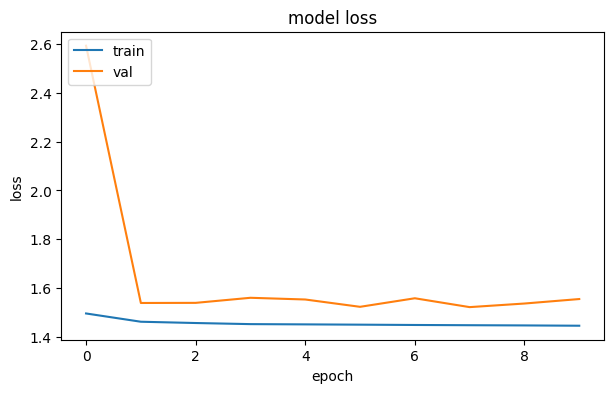

In [34]:
plot_learning_curve(protein_history['train_loss'], protein_history['val_loss'], 'model loss')


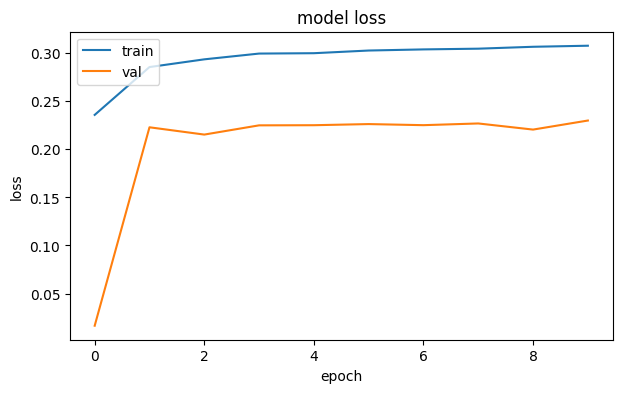

In [35]:
plot_learning_curve(protein_history['train_cor'], protein_history['val_cor'], 'model loss')

## Prediction

In [36]:
def predict(model, x, device='cpu', batch_size=512):
    """x: numpy array or tensor of features (already built, single modality).
    Returns predictions as a 1D numpy array."""
    model.to(device)
    model.eval()
    if not torch.is_tensor(x):
        x = torch.from_numpy(x)
    preds = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i + batch_size].to(device)
            preds.append(model(xb).cpu())
    return torch.cat(preds).numpy()



In [52]:
dm_drug_pred_lco_test = predict(drug_model, drug_X_lco_test)
dm_drug_pred_ldo_test = predict(drug_model, drug_X_ldo_test)
dm_drug_pred_lto_test = predict(drug_model, drug_X_lto_test)
dm_drug_pred_lpo_test = predict(drug_model, drug_X_lpo_test)

In [43]:
rm_rna_pred_lco_test = predict(rna_model, rna_X_lco_test)
rm_rna_pred_ldo_test = predict(rna_model, rna_X_ldo_test)
rm_rna_pred_lto_test = predict(rna_model, rna_X_lto_test)
rm_rna_pred_lpo_test = predict(rna_model, rna_X_lpo_test)

In [37]:
pm_protein_pred_lco_test = predict(protein_model, protein_X_lco_test)
pm_protein_pred_ldo_test = predict(protein_model, protein_X_ldo_test)
pm_protein_pred_lto_test = predict(protein_model, protein_X_lto_test)
pm_protein_pred_lpo_test = predict(protein_model, protein_X_lpo_test)

## Evaluation

In [38]:
def evaluateMT(target, pred, threshold=None):
    """
    threshold: cutoff for binarizing target into sensitive/resistant for ROC-AUC.
    Defaults to median of target if not provided.
    """
    variance_real = np.var(target)
    variance_pred = np.var(pred)
    mean_real = np.mean(target)
    mean_pred = np.mean(pred)
    mses = ((target - pred)**2).mean(axis=0)
    rmse = np.sqrt(mses)
    correlation, corr_p_value = pearsonr(target, pred)
    spearman_corr, spearman_p = spearmanr(target, pred)
    r2 = r2_score(target, pred)
    slope, intercept, r_value, lr_p_value, std_err = linregress(pred, target)

    if threshold is None:
        threshold = np.median(target)
    target_binary = (target < threshold).astype(int)  # 1 = sensitive (lower IC50)
    if len(np.unique(target_binary)) == 2:
        roc_auc = roc_auc_score(target_binary, -pred)  # lower predicted IC50 = more sensitive
    else:
        roc_auc = np.nan  # all-one-class fold, AUC undefined

    results = {
        'Correlation': round(correlation, 2),
        'Corr p-value': round(corr_p_value, 4),
        'Spearman': round(spearman_corr, 2),
        'MSE': round(mses, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 2),
        'ROC-AUC': round(roc_auc, 2) if not np.isnan(roc_auc) else roc_auc,
        'Slope': round(slope, 2),
        'Standard error': round(std_err, 2),
        'Variance Real': round(variance_real, 2),
        'Variance Pred': round(variance_pred, 2)
    }

    return pd.DataFrame([results])

In [39]:
fold_idx = 0
cell_holdout = set(holdout_groups[fold_idx]["cell_lines_held_out"])
drug_holdout = set(holdout_groups[fold_idx]["drugs_held_out"])

lpo_idx = np.array(folds[fold_idx]["lpo_test"])
sub = pairs.loc[lpo_idx]  # same row order as lpo_idx -> aligns with y_lpo_test / preds
is_new_cell = sub[COL_CELLOSAURUS].isin(cell_holdout).to_numpy()
is_new_drug = sub[COL_DRUG].isin(drug_holdout).to_numpy()
n_new = is_new_cell.astype(int) + is_new_drug.astype(int)

lpo_masks = {
    "LPO - nothing new": (~is_new_cell) & (~is_new_drug),
    "LPO - new cell line only": is_new_cell & (~is_new_drug),
    "LPO - new drug only": (~is_new_cell) & is_new_drug,
    "LPO - fully new (cell AND drug)": is_new_cell & is_new_drug,
}

for name, mask in lpo_masks.items():
    print(f"{name}: n={mask.sum():,}")

LPO - nothing new: n=16,599
LPO - new cell line only: n=1,823
LPO - new drug only: n=1,971
LPO - fully new (cell AND drug): n=220


In [55]:
splits = {
    'LCO': (y_lco_test, dm_drug_pred_lco_test),
    'LTO': (y_lto_test, dm_drug_pred_lto_test),
    'LDO': (y_ldo_test, dm_drug_pred_ldo_test),
}

results_list = []
for split_name, (y_true, y_pred) in splits.items():
    df = evaluateMT(y_true, y_pred)
    df.insert(0, 'Split', split_name)
    results_list.append(df)

# LPO, broken into nothing-new / partially-new / fully-new
df = evaluateMT(y_lpo_test, dm_drug_pred_lpo_test)
df.insert(0, 'Split', 'LPO - all')
results_list.append(df)

for name, mask in lpo_masks.items():
    df = evaluateMT(y_lpo_test[mask], dm_drug_pred_lpo_test[mask])
    df.insert(0, 'Split', name)
    results_list.append(df)

results_df = pd.concat(results_list, ignore_index=True)
results_df


,Split,Correlation,Corr p-value,Spearman,MSE,RMSE,R2,ROC-AUC,Slope,Standard error,Variance Real,Variance Pred
0,LCO,0.73,0.0000,0.64,3.43,1.85,0.52,0.82,0.93,0.01,7.16,4.40
1,LTO,0.74,0.0000,0.66,4.24,2.06,0.44,0.82,0.97,0.01,7.54,4.43
2,LDO,0.11,0.0000,0.12,7.03,2.65,-0.08,0.54,0.27,0.02,6.52,1.12
3,LPO - all,0.73,0.0000,0.64,3.40,1.84,0.53,0.82,0.94,0.01,7.27,4.46
4,LPO - nothing new,0.77,0.0000,0.70,3.01,1.73,0.59,0.84,0.95,0.01,7.42,4.86
5,LPO - new cell line only,0.77,0.0000,0.68,2.95,1.72,0.59,0.84,0.93,0.02,7.16,4.92
6,LPO - new drug only,0.12,0.0000,0.13,6.63,2.58,-0.08,0.54,0.28,0.05,6.14,1.12
7,LPO - fully new (cell AND drug),0.16,0.0167,0.20,7.16,2.68,-0.02,0.60,0.44,0.18,7.03,0.95


In [44]:
splits = {
    'LCO': (y_lco_test, rm_rna_pred_lco_test),
    'LTO': (y_lto_test, rm_rna_pred_lto_test),
    'LDO': (y_ldo_test, rm_rna_pred_ldo_test),
}

results_list = []
for split_name, (y_true, y_pred) in splits.items():
    df = evaluateMT(y_true, y_pred)
    df.insert(0, 'Split', split_name)
    results_list.append(df)

# LPO, broken into nothing-new / partially-new / fully-new
df = evaluateMT(y_lpo_test, rm_rna_pred_lpo_test)
df.insert(0, 'Split', 'LPO - all')
results_list.append(df)

for name, mask in lpo_masks.items():
    df = evaluateMT(y_lpo_test[mask], rm_rna_pred_lpo_test[mask])
    df.insert(0, 'Split', name)
    results_list.append(df)

results_df = pd.concat(results_list, ignore_index=True)
results_df

,Split,Correlation,Corr p-value,Spearman,MSE,RMSE,R2,ROC-AUC,Slope,Standard error,Variance Real,Variance Pred
0,LCO,0.20,0.0000,0.20,7.40,2.72,-0.03,0.60,0.70,0.03,7.16,0.56
1,LTO,0.25,0.0000,0.24,7.37,2.71,0.02,0.61,0.85,0.02,7.54,0.67
2,LDO,0.27,0.0000,0.30,6.42,2.53,0.02,0.65,0.82,0.02,6.52,0.69
3,LPO - all,0.28,0.0000,0.30,7.11,2.67,0.02,0.64,0.92,0.02,7.27,0.70
4,LPO - nothing new,0.30,0.0000,0.32,7.18,2.68,0.03,0.65,0.96,0.02,7.42,0.71
5,LPO - new cell line only,0.17,0.0000,0.18,7.51,2.74,-0.05,0.58,0.59,0.08,7.16,0.56
6,LPO - new drug only,0.27,0.0000,0.32,6.10,2.47,0.01,0.65,0.80,0.06,6.14,0.70
7,LPO - fully new (cell AND drug),0.15,0.0215,0.19,7.53,2.74,-0.07,0.56,0.55,0.24,7.03,0.55


In [40]:
splits = {
    'LCO': (y_lco_test, pm_protein_pred_lco_test),
    'LTO': (y_lto_test, pm_protein_pred_lto_test),
    'LDO': (y_ldo_test, pm_protein_pred_ldo_test),
}

results_list = []
for split_name, (y_true, y_pred) in splits.items():
    df = evaluateMT(y_true, y_pred)
    df.insert(0, 'Split', split_name)
    results_list.append(df)

# LPO, broken into nothing-new / partially-new / fully-new
df = evaluateMT(y_lpo_test, pm_protein_pred_lpo_test)
df.insert(0, 'Split', 'LPO - all')
results_list.append(df)

for name, mask in lpo_masks.items():
    df = evaluateMT(y_lpo_test[mask], pm_protein_pred_lpo_test[mask])
    df.insert(0, 'Split', name)
    results_list.append(df)

results_df = pd.concat(results_list, ignore_index=True)
results_df

,Split,Correlation,Corr p-value,Spearman,MSE,RMSE,R2,ROC-AUC,Slope,Standard error,Variance Real,Variance Pred
0,LCO,0.20,0.0000,0.23,7.29,2.70,-0.02,0.61,0.80,0.03,7.16,0.47
1,LTO,0.22,0.0000,0.23,7.71,2.78,-0.02,0.60,0.97,0.03,7.54,0.37
2,LDO,0.29,0.0000,0.33,6.27,2.50,0.04,0.66,0.94,0.02,6.52,0.62
3,LPO - all,0.29,0.0000,0.31,7.03,2.65,0.03,0.65,1.00,0.02,7.27,0.62
4,LPO - nothing new,0.31,0.0000,0.32,7.10,2.66,0.04,0.66,1.04,0.03,7.42,0.64
5,LPO - new cell line only,0.15,0.0000,0.18,7.47,2.73,-0.04,0.58,0.61,0.09,7.16,0.46
6,LPO - new drug only,0.29,0.0000,0.34,5.97,2.44,0.03,0.67,0.91,0.07,6.14,0.63
7,LPO - fully new (cell AND drug),0.12,0.0831,0.17,7.61,2.76,-0.08,0.54,0.45,0.26,7.03,0.48


## Graph Drug

In [15]:
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

In [ ]:
# ---- Build drug graphs  ----
drug_graphs = build_drug_graphs(drug_smiles)
print(f"Graphs: {len(drug_graphs)} / {drug_smiles[COL_DRUG].nunique()} drugs")

Graphs: 246 / 246 drugs


### Graph dataset: pairs an index of (cell, drug, y) rows to drug graphs

In [ ]:
class DrugGraphDataset(Dataset):
    """Maps response-pair rows to (drug graph, IC50) examples. Drops rows whose
    drug has no valid graph (failed SMILES parse) instead of crashing."""
    def __init__(self, idx: np.ndarray, drug_graphs: dict, target_col: str = COL_IC50):
        sub = pairs.loc[idx]
        has_graph = sub[COL_DRUG].isin(drug_graphs)
        n_dropped = (~has_graph).sum()
        if n_dropped:
            print(f"Dropping {n_dropped} rows with no valid drug graph")
        self.sub = sub[has_graph].reset_index(drop=True)
        self.drug_graphs = drug_graphs
        self.y = self.sub[target_col].to_numpy().astype(np.float32)

    def __len__(self):
        return len(self.sub)

    def __getitem__(self, i):
        graph = self.drug_graphs[self.sub.loc[i, COL_DRUG]]
        return Data(x=graph.x, edge_index=graph.edge_index,
                    y=torch.tensor([self.y[i]], dtype=torch.float))


def make_graph_dataloader(idx: np.ndarray, drug_graphs: dict, batch_size: int, shuffle: bool) -> GeoDataLoader:
    dataset = DrugGraphDataset(idx, drug_graphs)
    return GeoDataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)

### DrugGNN model

In [ ]:

class DrugGNN(nn.Module):
    def __init__(self, in_dim: int = 6, hidden: int = 256, out_dim: int = 256, dropout_prob: float = 0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout_prob)
        self.head = nn.Linear(out_dim, 1)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        return self.head(x).squeeze(-1)

### Dataloaders

In [ ]:

gnn_train_loader = make_graph_dataloader(train_inner_idx, drug_graphs, batch_size=64, shuffle=True)
gnn_val_loader = make_graph_dataloader(val_idx, drug_graphs, batch_size=64, shuffle=False)
gnn_data_loaders = {"train": gnn_train_loader, "val": gnn_val_loader}

gnn_lco_loader = make_graph_dataloader(np.array(folds[0]["lco_test"]), drug_graphs, batch_size=512, shuffle=False)
gnn_ldo_loader = make_graph_dataloader(np.array(folds[0]["ldo_test"]), drug_graphs, batch_size=512, shuffle=False)
gnn_lto_loader = make_graph_dataloader(np.array(folds[0]["lto_test"]), drug_graphs, batch_size=512, shuffle=False)
gnn_lpo_loader = make_graph_dataloader(np.array(folds[0]["lpo_test"]), drug_graphs, batch_size=512, shuffle=False)

### Model, optimizer

In [ ]:

gnn_model = DrugGNN(in_dim=6, hidden=256, out_dim=256)
print(f"DrugGNN parameters: {count_parameters(gnn_model):,}")

optimizer_gnn = torch.optim.Adam(gnn_model.parameters(), lr=1e-4, weight_decay=1e-4)

DrugGNN parameters: 134,657


In [31]:
criterion = nn.HuberLoss()

### Training loop

In [ ]:

def fit_gnn(model, data_loaders, optimizer, criterion, num_epochs, patience, checkpoint_path, device):
    history = {"train_loss": [], "train_cor": [], "val_loss": [], "val_cor": []}
    best_val_mse = float("inf")
    best_weights = None
    wait = 0
    stop_training = False

    print("Starting training...")
    for epoch in range(num_epochs):
        if stop_training:
            break
        print(f"Epoch {epoch + 1}/{num_epochs}")

        for phase in ["val", "train"]:
            phase_device = device if phase == "train" else torch.device("cpu")
            model.to(phase_device)
            model.train() if phase == "train" else model.eval()

            batch_losses = []
            preds, targets = [], []

            for batch in tqdm(data_loaders[phase], total=len(data_loaders[phase]), desc=phase):
                batch = batch.to(phase_device)
                y = batch.y.squeeze(-1)

                if phase == "train":
                    optimizer.zero_grad()
                    pred = model(batch.x, batch.edge_index, batch.batch)
                    loss = criterion(pred, y)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        pred = model(batch.x, batch.edge_index, batch.batch)
                        loss = criterion(pred, y)

                batch_losses.append(loss.item())
                preds.append(pred.detach())
                targets.append(y.detach())

            epoch_mse = sum(batch_losses) / len(batch_losses)
            all_preds = torch.cat(preds).cpu().numpy()
            all_targets = torch.cat(targets).cpu().numpy()
            epoch_cor, _ = pearsonr(all_targets, all_preds)

            history[f"{phase}_loss"].append(epoch_mse)
            history[f"{phase}_cor"].append(epoch_cor)
            print(f"  {phase}: loss={epoch_mse:.4f}  pearson_r={epoch_cor:.4f}")

            if phase == "val":
                if epoch_mse < best_val_mse:
                    best_val_mse = epoch_mse
                    best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f"Early stopping at epoch {epoch + 1}")
                        stop_training = True

    if best_weights is not None:
        model.load_state_dict(best_weights)
        torch.save(best_weights, checkpoint_path)
        print(f"Best val Loss: {best_val_mse:.4f} -- saved to {checkpoint_path}")

    return model, history


In [34]:
num_epochs=10
patience=5
checkpoint_path = RESULTS_DIR / "checkpoints/gnn_model.pt"

In [36]:
gnn_checkpoint_path = RESULTS_DIR / "checkpoints/gnn_drug_model.pt"
gnn_model, gnn_history = fit_gnn(gnn_model, gnn_data_loaders, optimizer_gnn, criterion,
                                  num_epochs, patience, gnn_checkpoint_path, DEVICE)

Starting training...
Epoch 1/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=1.3259  pearson_r=0.4832


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=1.1383  pearson_r=0.6465
Epoch 2/10


...

  train: loss=1.0929  pearson_r=0.6750
Epoch 8/10


val:   0%|          | 0/442 [00:00<?, ?it/s]

  val: loss=1.3004  pearson_r=0.4848
Early stopping at epoch 8


train:   0%|          | 0/1237 [00:00<?, ?it/s]

  train: loss=1.0815  pearson_r=0.6815
Best val Loss: 1.2946 -- saved to /content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/gnn_drug_model.pt


### Predict

In [ ]:
def predict_gnn(model, loader, device="cpu"):
    model.to(device)
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.batch)
            preds.append(pred.cpu())
            targets.append(batch.y.squeeze(-1).cpu())
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

In [38]:
gnn_pred_lco_test, gnn_y_lco_test = predict_gnn(gnn_model, gnn_lco_loader)
gnn_pred_ldo_test, gnn_y_ldo_test = predict_gnn(gnn_model, gnn_ldo_loader)
gnn_pred_lto_test, gnn_y_lto_test = predict_gnn(gnn_model, gnn_lto_loader)
gnn_pred_lpo_test, gnn_y_lpo_test = predict_gnn(gnn_model, gnn_lpo_loader)

### Evaluate

In [40]:
fold_idx = 0
cell_holdout = set(holdout_groups[fold_idx]["cell_lines_held_out"])
drug_holdout = set(holdout_groups[fold_idx]["drugs_held_out"])

lpo_idx = np.array(folds[fold_idx]["lpo_test"])
sub = pairs.loc[lpo_idx]  # same row order as lpo_idx -> aligns with y_lpo_test / preds
is_new_cell = sub[COL_CELLOSAURUS].isin(cell_holdout).to_numpy()
is_new_drug = sub[COL_DRUG].isin(drug_holdout).to_numpy()
n_new = is_new_cell.astype(int) + is_new_drug.astype(int)

lpo_masks = {
    "LPO - nothing new": (~is_new_cell) & (~is_new_drug),
    "LPO - new cell line only": is_new_cell & (~is_new_drug),
    "LPO - new drug only": (~is_new_cell) & is_new_drug,
    "LPO - fully new (cell AND drug)": is_new_cell & is_new_drug,
}

for name, mask in lpo_masks.items():
    print(f"{name}: n={mask.sum():,}")

LPO - nothing new: n=16,599
LPO - new cell line only: n=1,823
LPO - new drug only: n=1,971
LPO - fully new (cell AND drug): n=220


In [41]:
splits = {
    'LCO': (gnn_y_lco_test, gnn_pred_lco_test),
    'LTO': (gnn_y_lto_test, gnn_pred_lto_test),
    'LDO': (gnn_y_ldo_test, gnn_pred_ldo_test),
}

results_list = []
for split_name, (y_true, y_pred) in splits.items():
    df = evaluateMT(y_true, y_pred)
    df.insert(0, 'Split', split_name)
    results_list.append(df)

# LPO, broken into nothing-new / partially-new / fully-new
df = evaluateMT(gnn_y_lpo_test, gnn_pred_lpo_test)
df.insert(0, 'Split', 'LPO - all')
results_list.append(df)

for name, mask in lpo_masks.items():
    df = evaluateMT(gnn_y_lpo_test[mask], gnn_pred_lpo_test[mask])
    df.insert(0, 'Split', name)
    results_list.append(df)

results_df = pd.concat(results_list, ignore_index=True)
results_df

,Split,Correlation,Corr p-value,Spearman,MSE,RMSE,R2,ROC-AUC,Slope,Standard error,Variance Real,Variance Pred
0,LCO,0.61,0.0000,0.50,4.86,2.20,0.32,0.74,1.02,0.01,7.16,2.56
1,LTO,0.62,0.0000,0.53,6.34,2.52,0.16,0.76,1.07,0.01,7.54,2.57
2,LDO,0.13,0.0000,0.12,7.47,2.73,-0.15,0.57,0.31,0.02,6.52,1.14
3,LPO - all,0.61,0.0000,0.50,4.79,2.19,0.34,0.74,1.02,0.01,7.27,2.63
4,LPO - nothing new,0.65,0.0000,0.55,4.52,2.13,0.39,0.76,1.06,0.01,7.42,2.81
5,LPO - new cell line only,0.64,0.0000,0.52,4.49,2.12,0.37,0.76,1.06,0.03,7.16,2.62
6,LPO - new drug only,0.15,0.0000,0.15,7.02,2.65,-0.14,0.57,0.35,0.05,6.14,1.13
7,LPO - fully new (cell AND drug),0.11,0.1136,0.08,8.12,2.85,-0.15,0.54,0.27,0.17,7.03,1.10
